This notebooks contains all the analysis from the paper related to the contact-THM problem **(Sequence B)**.
It loads the data from the `stats/` folder.

The headings in the notebook correspond to the sections of the paper.

In [1]:
from load_experiments_data import load_experiments_data_thm, make_pandas
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.rcdefaults()
font = 8
tex_fonts = {
    "font.family": "serif",
    "font.size": font,
    "axes.labelsize": font,
    "axes.titlesize": font,
    "xtick.labelsize": font,
    "ytick.labelsize": font,
    "legend.fontsize": font,
}


sns.set_theme(
    context="paper",
    style="whitegrid",
    rc=tex_fonts,
)

ALL_RUNS = [200, 201, 202, 203, 204]
Path('figures/').mkdir(exist_ok=True)

# 6.1 Collecting Statistics

In [2]:
sim_data_random, perf_data_random, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS, case='random'
)
solver_space = solver_selector.solver_space
num_solvers = solver_space.all_decisions_encoding.shape[0]
print('Num solvers:', num_solvers)
print('Num category choices:', solver_space.num_category_choices)
print('Num numerical choices:', solver_space.num_numerical_choices)

Num solvers: 32000
Num category choices: 21
Num numerical choices: 10


In [3]:
df_sim_rand, df_perf_rand = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)

df_perf_rand.tail()

,seq_id,sim_idx,reward,expectation,decision_idx,features,predict_time,fit_time
21656,204,24,-0.759560,100.0,16883,"[86400000.0, 312.99983841285393, 392.997066598...",0.000403,0.000004
21657,204,24,-200.000000,100.0,31086,"[48503837.43526125, 312.9998384128531, 392.997...",0.000384,0.000003
21658,204,24,-1.049917,100.0,21518,"[48503837.43526125, 312.9998384128531, 392.997...",0.000484,0.000004
21659,204,24,-0.964965,100.0,22140,"[48503837.43526125, 312.9998442798641, 392.997...",0.000383,0.000004
21660,204,24,-0.891668,100.0,21220,"[48503837.43526125, 312.9998442892693, 392.997...",0.000413,0.000003


The cell below does this:
1. We store the performance data for each configuration separately;
2. We find the mean run time for each configuration;
3. We sort the configurations based on the mean run time and plot it.

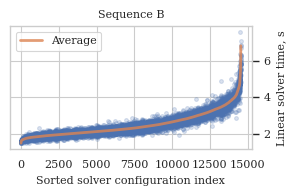

In [4]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf_rand.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

mean = []
std = []
for elem in y_by_solver_id:
    if len(elem) != 0:
        mean.append(np.mean(elem))
        std.append(np.std(elem))
    else:
        mean.append(np.nan)
        std.append(np.nan)

mean = np.array(mean)
std = np.array(std)

sorted_idx = np.argsort(mean)

idx = []
data = []
i = 0
for y in np.array(y_by_solver_id, dtype=object)[sorted_idx]:
    data.extend(y)
    idx.extend([i] * len(y))
    i += 1

plt.figure(figsize=(3,2))
plt.plot(mean[sorted_idx], color='C1', alpha=0.8, linewidth=2, label='Average')
plt.scatter(idx, data, marker='.', alpha=0.2, s=30)
# plt.ylim(1, 20)
# plt.yscale('log')
plt.grid(True)
plt.xlabel('Sorted solver configuration index')
plt.ylabel('Linear solver time, s')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence B')
plt.tight_layout()

plt.savefig('figures/thm_sorted_run_times.png', dpi=600)

In [5]:
solver_selection_mean = 1.8  # this is the mean run time in the solver selection experiment (we get this number in Section 6.2, below)
print('The mean solver with solver selection corresponds to % best on the histogram above:', (mean[sorted_idx] < solver_selection_mean).sum() / mean.size * 100)

The mean solver with solver selection corresponds to % best on the histogram above: 2.39375


Below, we compute statistics for the table in Section 6.1

In [6]:
num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

14300 1258 244


In [7]:
import pandas as pd

success = df_perf_rand.reward > -200
ysuccess = np.exp(-df_perf_rand[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'Num. solver configurations': [num_solvers],
    'Num. data points': df_perf_rand.shape[0],
    'Configurations tried, %': num_solvers_tried / num_solvers * 100,
    'Success rate, %': np.sum(success) / success.size * 100,
    'Always success, %': num_always_success / num_solvers_tried * 100,
    'Always failure, %': num_always_failure / num_solvers_tried * 100,
    # 'Swinging, %': num_swinging / num_solvers_tried * 100,
    'Run time average, s': ysuccess.mean(),
    'Run time median, s': ysuccess.median(),
    'Run time min, s': ysuccess.min(),
    'Run time max, s': ysuccess.max(),
}
pd.DataFrame(stats).T.round(2)

,0
Num. solver configurations,32000.00
Num. data points,21661.00
"Configurations tried, %",49.38
"Success rate, %",91.33
"Always success, %",90.49
"Always failure, %",7.96
"Run time average, s",2.48
"Run time median, s",2.28
"Run time min, s",1.46
"Run time max, s",7.60


# 6.2 Solver Selection Experiment

In [8]:
sim_data, perf_data, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS, case='solver_selection'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim, df_perf = make_pandas(
    sim_data=sim_data,
    perf_data=perf_data,
    seq_ids=ALL_RUNS,
)
df_perf.head()

,seq_id,sim_idx,reward,expectation,decision_idx,features,predict_time,fit_time
0,200,0,-0.911124,100.0,5492,"[86400.0, 393.0, 393.0, 2.759353900791754e-16,...",0.000418,0.000011
1,200,0,-0.723189,100.0,17536,"[86400.0, 392.9544882870406, 393.6343350751995...",0.000381,0.000011
2,200,0,-0.706616,100.0,17539,"[86400.0, 392.9544460196949, 393.1042580885859...",0.000359,0.000014
3,200,0,-1.037605,100.0,31287,"[86400.0, 392.95444601969155, 393.104206878979...",0.000372,0.000016
4,200,0,-1.124336,100.0,27999,"[86400.0, 392.95444601969155, 393.104206878980...",0.000394,0.000013


Below, we compute statistics for the table in Section 6.2

In [9]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

595 17 1


In [10]:
import pandas as pd

batch_size = 64
success = df_perf.reward > -200
ysuccess = np.exp(-df_perf[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'Num. solver configurations': [num_solvers],
    'Num. data points': df_perf.shape[0],
    'Configurations tried, %': num_solvers_tried / num_solvers * 100,
    'Success rate after init. expl., %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    # '% num_always_success': num_always_success / num_solvers_tried * 100,
    # '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    # '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time average, s': ysuccess.mean(),
    'Run time median, s': ysuccess.median(),
    'Run time min, s': ysuccess.min(),
    'Run time max, s': ysuccess.max(),
}
pd.DataFrame(stats).T.round(2)

,0
Num. solver configurations,32000.00
Num. data points,19878.00
"Configurations tried, %",1.92
"Success rate after init. expl., %",99.69
"Run time average, s",1.80
"Run time median, s",1.78
"Run time min, s",1.32
"Run time max, s",4.91


The cells below make various figures for Section 6.2

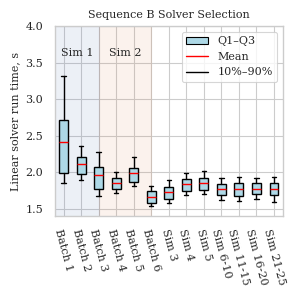

In [11]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

batches = range(6)
perf_data_per_batch = []

for bstart in batches:
    bend = bstart + 1
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())

sims = [[2], [3], [4], list(range(5,10)), list(range(10,15)), list(range(15,20)), list(range(20,25))]

for sim_id in sims:
    tmp = df_perf[df_perf.sim_idx.isin(sim_id)]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_batch.append(np.array(y))


plt.figure(figsize=(3, 3))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[10, 90],
)

plt.axvspan(0, 3, alpha=0.1, color='C0')
plt.axvspan(3, 6, alpha=0.1, color='C1')
plt.xticks(
    range(1, len(perf_data_per_batch) + 1),
    [f'Batch {i+1}' for i in batches] + [f'Sim {x[0]+1}' if len(x)==1 else f'Sim {min(x)+1}-{max(x)+1}' for x in sims],
    rotation=-75
)
plt.text(1.8, 3.6, 'Sim 1', ha='center')
plt.text(4.5, 3.6, 'Sim 2', ha='center')

plt.xlim(left=0.5)
plt.title('Sequence B Solver Selection')

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
whiskers_legend = mlines.Line2D([], [], color='black', linewidth=1, label='10%–90%')
plt.legend(handles=[iqr_box, mean_line, whiskers_legend], loc='upper right')

plt.ylim(top=4, bottom=1.4)
plt.ylabel(r"Linear solver run time, s")
plt.tight_layout()
plt.savefig("figures/thm_boxplot_batches_and_simulations.png", dpi=600)

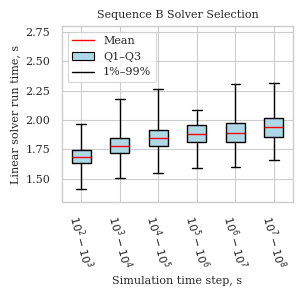

In [12]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

tmp = df_sim[df_sim.sim_idx.isin(range(15, 25))]
x = np.array(tmp.simulation_dt)
y = np.array(tmp.real_solve_time)
filter = (y < 7) & (y > 0.0002)  # drop failures and anomalies
x = x[filter]
y = y[filter]

bins = 10.0 ** np.arange(2, 9)
perf_data_per_dt = []
xticklabels = []
for bin_start, bin_end in zip(bins[:-1], bins[1:]):
    perf_data_per_dt.append(y[(x >= bin_start) & (x < bin_end)])
    pow = int(np.log10(bin_start))
    xticklabels.append("$10^{" + str(pow) + "} - 10^{" + str(pow + 1) + "}$")


plt.figure(figsize=(3, 3))
plt.boxplot(
    perf_data_per_dt,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[1, 99],
)
plt.xticks(np.arange(1, len(bins)), xticklabels, rotation=-75)
plt.title("Sequence B Solver Selection")

plt.xlabel('Simulation time step, s')
plt.ylabel(r"Linear solver run time, s")

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
whiskers_legend = mlines.Line2D([], [], color='black', linewidth=1, label='1%–99%')
plt.legend(handles=[mean_line, iqr_box, whiskers_legend], loc='upper left')
# plt.ylim(top=7)

plt.tight_layout()
plt.savefig("figures/thm_boxplot_sim_dt.png", dpi=600)

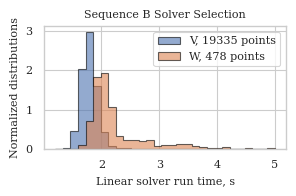

In [13]:
import pandas as pd
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)


perf_dict_for_pandas = []
for row in df_perf.itertuples(index=False):
    decision_vec = solver_space.all_decisions_encoding[row.decision_idx]
    perf_dict_for_pandas.append(
        {name: val for name, val in zip(decision_names, decision_vec)}
    )

column_dtypes = {x: bool for x in decision_names[:solver_space.num_category_choices]} 
column_dtypes |= {x: float for x in decision_names[solver_space.num_category_choices:]} 
tmp = pd.DataFrame(perf_dict_for_pandas).astype(column_dtypes)

df_perf_detailed = pd.concat([df_perf, tmp], axis=1)
df_perf_detailed['time'] = np.exp(-df_perf_detailed.reward)
df_perf_detailed = df_perf_detailed.drop('features', axis=1)
df_perf_detailed

def make_hist(df: pd.DataFrame, label: str):
    bins = 30
    bins = np.linspace(1.2, 5, bins, endpoint=True)
    y = df.reward[df.reward > -200]
    y = np.exp(-y)
    plt.hist(y, label=f'{label}, {y.size} points', alpha=0.6, bins=bins, density=True, edgecolor="black", histtype='stepfilled')

plt.figure(figsize=(3,2))
make_hist(df_perf_detailed[df_perf_detailed['hypre - V'] == True], label='V')
make_hist(df_perf_detailed[df_perf_detailed['hypre - W'] == True], label='W')
plt.ylabel('Normalized distributions')
plt.xlabel('Linear solver run time, s')
plt.title('Sequence B Solver Selection')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/thm_v_vs_w.png', dpi=600)

Mean selection overhead, s: 0.010471919761648213 +- 0.0016475656638575713


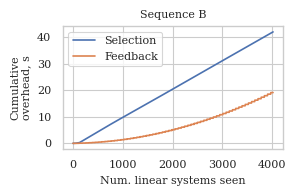

In [14]:
plt.figure(figsize=(3,2))
selection_overhead = np.array(df_perf[df_perf.seq_id == ALL_RUNS[4]].predict_time)
feedback_overhead = np.array(df_perf[df_perf.seq_id == ALL_RUNS[4]].fit_time)
plt.plot(np.cumsum(selection_overhead), label='Selection')
plt.plot(np.cumsum(feedback_overhead), label='Feedback')
plt.legend()
plt.ylabel('Cumulative\noverhead, s')
plt.xlabel('Num. linear systems seen')
plt.title('Sequence B')
plt.tight_layout()
plt.savefig('figures/thm_ml_overhead.png', dpi=600)
print('Mean selection overhead, s:', selection_overhead.mean(), '+-', selection_overhead.std())

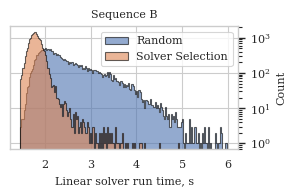

In [15]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])

bins = 200
upper_lim = 6
bins = np.linspace(min(data_rand), upper_lim, bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random', histtype='stepfilled')
plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection', histtype='stepfilled')

plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
plt.yscale('log')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence B')
plt.tight_layout()
# plt.savefig('figures/thm_runtime_histogram.png', dpi=600)

# 6.3 Comparing Againts Optimal Solver

In [16]:
sim_data_expert, perf_data_expert, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS,
    case='expert'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim_expert, df_perf_expert = make_pandas(
    sim_data=sim_data_expert,
    perf_data=perf_data_expert,
    seq_ids=ALL_RUNS,
)
df_sim_expert.tail()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
19805,204,24,52,1,1.806715,39,2,12.025392,8.640000e+07,0.002050,0.000011,9.860903e-08,6.434559e-09
19806,204,24,52,2,1.721434,34,2,12.025392,8.640000e+07,0.002050,0.000011,9.860899e-08,6.434233e-09
19807,204,24,53,0,1.899012,45,2,6.750899,4.850384e+07,0.002050,0.000011,9.860899e-08,6.434233e-09
19808,204,24,53,1,1.794242,38,2,6.750898,4.850384e+07,0.002043,0.000011,1.022220e-07,6.507295e-09
19809,204,24,53,2,1.718626,34,2,6.750898,4.850384e+07,0.002043,0.000011,1.022217e-07,6.507112e-09


In [17]:
import pandas as pd

success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf_expert.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)

success = df_perf_expert.reward > -200
ysuccess = np.exp(-df_perf_expert[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,32000.000000
num_points,19810.000000
% solvers_tried,0.175000
Success %,100.000000
Run time avg,1.750673
Run time median,1.751708
Run time min,1.308138
Run time max,2.453192


In [18]:
sim_data_petsc_default, perf_data_petsc_default, _ = load_experiments_data_thm(
    runs=ALL_RUNS, case='petsc_default'
)

df_sim_petsc_default, df_perf_petsc_default = make_pandas(
    sim_data=sim_data_petsc_default,
    perf_data=perf_data_petsc_default,
    seq_ids=ALL_RUNS,
)
df_sim_petsc_default.tail()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
19805,204,24,52,1,2.820378,28,2,12.025392,8.640000e+07,0.002050,0.000011,9.860903e-08,6.434559e-09
19806,204,24,52,2,2.687805,25,2,12.025392,8.640000e+07,0.002050,0.000011,9.860899e-08,6.434233e-09
19807,204,24,53,0,2.928189,32,2,6.750899,4.850384e+07,0.002050,0.000011,9.860899e-08,6.434233e-09
19808,204,24,53,1,2.801432,27,2,6.750898,4.850384e+07,0.002043,0.000011,1.022220e-07,6.507295e-09
19809,204,24,53,2,2.633332,25,2,6.750898,4.850384e+07,0.002043,0.000011,1.022217e-07,6.507112e-09


In [19]:
import pandas as pd

success = df_perf_petsc_default.reward > -200
ysuccess = np.exp(-df_perf_petsc_default[success].reward)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,32000.000000
num_points,19810.000000
Success %,100.000000
Run time avg,2.589023
Run time median,2.574148
Run time min,2.100946
Run time max,3.374724


Mean run time random: 11550.67817454338
Mean run time petsc default: 10551.594434261322
Mean run time expert: 7912.87560172081
Mean run time solver_selection 7537.036360740662


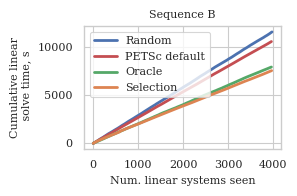

In [20]:
from scipy.interpolate import interp1d

plt.figure(figsize=(3,2))

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_rand.real_solve_time[df_sim_rand.seq_id == seq_id])
    y = np.cumsum(y)

    # plt.plot(y, color="C0", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 4000, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C0", linewidth=2, label='Random', alpha=1)
print('Mean run time random:', np.mean(resampled, axis=0).max())

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_petsc_default.real_solve_time[df_sim_petsc_default.seq_id == seq_id])
    y = np.cumsum(y)

    # plt.plot(y, color="C3", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C3", linewidth=2, label='PETSc default', alpha=1)
print('Mean run time petsc default:', np.mean(resampled, axis=0).max())

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim_expert.real_solve_time[df_sim_expert.seq_id == seq_id])
    y = np.cumsum(y)

    # plt.plot(y, color="C2", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 4000, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C2", linewidth=2, label='Oracle', alpha=1)
print('Mean run time expert:', np.mean(resampled, axis=0).max())

resampled = []
for seq_id in ALL_RUNS:
    y = np.array(df_sim.real_solve_time[df_sim.seq_id == seq_id])
    y = np.cumsum(y)
    # plt.plot(y, color="C1", alpha=0.4)

    x_old = np.arange(y.size)
    f = interp1d(x_old, y, kind="linear")
    x_new = np.linspace(0, len(x_old) - 1, 4000, endpoint=True)
    resampled.append(f(x_new))

plt.plot(x_new, np.mean(resampled, axis=0), color="C1", linewidth=2, label='Selection', alpha=1)
print('Mean run time solver_selection', np.mean(resampled, axis=0).max())

# plt.yticks([0, 10000, 17700, 27300])

plt.ylabel('Cumulative linear\n solve time, s')
plt.xlabel('Num. linear systems seen')
plt.legend(loc='upper left')
plt.title('Sequence B')

# plt.ylim(bottom=0, top=20000)
# plt.yscale('log')

plt.tight_layout()
plt.savefig('figures/thm_runtime_expert.png', dpi=600)

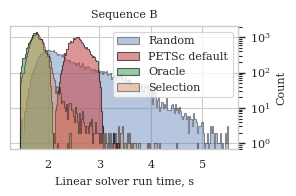

In [21]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])
data_expert = np.exp(-df_perf_expert.reward[df_perf_expert.reward > -200])
data_petsc_default = np.exp(-df_perf_petsc_default.reward[df_perf_petsc_default.reward > -200])

bins = 200
upper_lim = 5.5
bins = np.linspace(min(data_rand), upper_lim, bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.4, edgecolor="black", label='Random', histtype='stepfilled', color='C0')
plt.hist(data_petsc_default, bins=bins, density=False, alpha=0.6, edgecolor="black", label='PETSc default', histtype='stepfilled', color='C3')
plt.hist(data_expert, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Oracle', histtype='stepfilled', color='C2')
plt.hist(data, bins=bins, density=False, alpha=0.4, edgecolor="black", label='Selection', histtype='stepfilled', color='C1')


plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
plt.yscale('log')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence B')
plt.tight_layout()
plt.savefig('figures/thm_runtime_histogram.png', dpi=600)